# Rating analysis

The same questions are rated by the human evaluators **LZ** and **KB**, and by
the **Claude** and **Codex** LLM judges — each judge twice, once with the
reference solution in hand (*supervised*, columns `claude` / `codex`) and once
without it (*unsupervised*, columns `claude_unsup` / `codex_unsup`).

Throughout: *rater* = who gave the rating (LZ / KB / claude / codex);
*agent* = the system being evaluated (claude-code / codex).

LZ's rating is the reference — where a judge was once found more accurate,
that judgement was folded into LZ's own rating, so LZ stands alone as truth.

Everything comes from the `ratings` package next door; the rating workflow
itself is `python3 -m ratings` (see [RATINGS.md](RATINGS.md)).

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%load_ext autoreload
%autoreload 2

# The house style, same as metrics.py and the case-study notebook: seaborn
# "ticks" with the right and top spines dropped, and TrueType fonts so text in
# an exported PDF stays editable.
sns.set_theme(style="ticks", rc={"axes.spines.right": False,
                                "axes.spines.top": False})
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 300
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

from ratings import (add_combined, add_null, agreement, binary, categories,
                     drop_efficiency, display,
                     coverage_summary, load_ratings, plots, summary_table)

pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 120)

## 1. Load

Human ratings come from each evaluator's dossier copies; judge ratings from
`eval/<dataset>/judge_supervised/` and `judge_unsupervised/`, mapped onto our
question numbering by content rather than by number (the judges ask their own
list, and the two numberings have drifted apart).

A question whose variable the judge names differently — `position` against
"Position in corridor", `photostim` against "Photostimulation" — still pairs on
content. Anything that can only be paired by its *number* prints a WARNING on
stderr, and is worth reading: it is also what a dossier answering a genuinely
different question under the same number would look like. There should be none.

"How is memory usage optimized?" is dropped everywhere: it was added to the
references after the judges ran, so no judge ever answered it.

In [2]:
ratings = load_ratings()          # both judge runs; judge_modes= to pick one
ratings

Ratings(8 datasets, 1428 rows, LZ=1428, KB=1428, claude=1428, codex=1428, claude_unsup=1428, codex_unsup=1428)

### Coverage

Cells = questions x 6 trials. Gaps are real and stay as NaN rather than
becoming zeros: KB has not rated zhong2025, and is one question short in
three datasets.

In [3]:
_ = ratings.excluded # memory related questions are dropped
coverage_summary(ratings)

rater,LZ,KB,claude,codex,claude_unsup,codex_unsup,cells
dataset,,,,,,,
allen2p,174,174,174,174,174,174,174
lee2025,120,120,120,120,120,120,120
majnik2025,126,126,126,126,126,126,126
sosa2024,234,234,234,234,234,234,234
chen2024,180,180,180,180,180,180,180
hasnain2024,198,198,198,198,198,198,198
zhang2025,180,180,180,180,180,180,180
zhong2025,216,216,216,216,216,216,216


In [4]:
# `LZ_null` is LZ's own ratings shuffled: the same number of every rating
# level, but attached to the wrong trials. It is the floor to read the real
# raters against. Shuffled separately in each frame so its distribution matches
# whichever subset that table uses.
full_table = add_null(ratings.tidy)

# Every analysis below runs on `process_only`: the Code Efficiency questions
# are performance advice, not a check on whether the conversion is right, and
# both agreement and mistake-catching are about correctness. `full_table` is
# the whole set, kept for the coverage view above.
process_only = add_null(drop_efficiency(ratings.tidy))
print(f"{len(full_table)} rows total, {len(process_only)} after dropping "
      f"{sorted(set(full_table.category) - set(process_only.category))}")

1428 rows total, 1236 after dropping ['Code Efficiency']


## 2. Summary visualization

One column per dataset, one row per question, six cells per row (3 trials x
2 agents). Pass any rater.

The `Thresholding` sub-block is left out by default — only sosa2024 has those
two questions, so showing them costs a row band across every column.

`EXCLUDE_VARS` drops variables whose source and processing questions are
rated `match` in every trial: every cell the same color, so the row says
nothing. That is an editorial call, so it lives here rather than in the
package — edit the dict to change the figure. `uniform_variables(full_table)` lists
the candidates. Nothing here affects the numbers in sections 3 and 4.

In [5]:
EXCLUDE_VARS = {
    "sosa2024": ("input: Environment type", "input: Trial number",
                 "output: Reward outcome"),
    "zhong2025": ("input: reward_availability", "output: licking"),
}

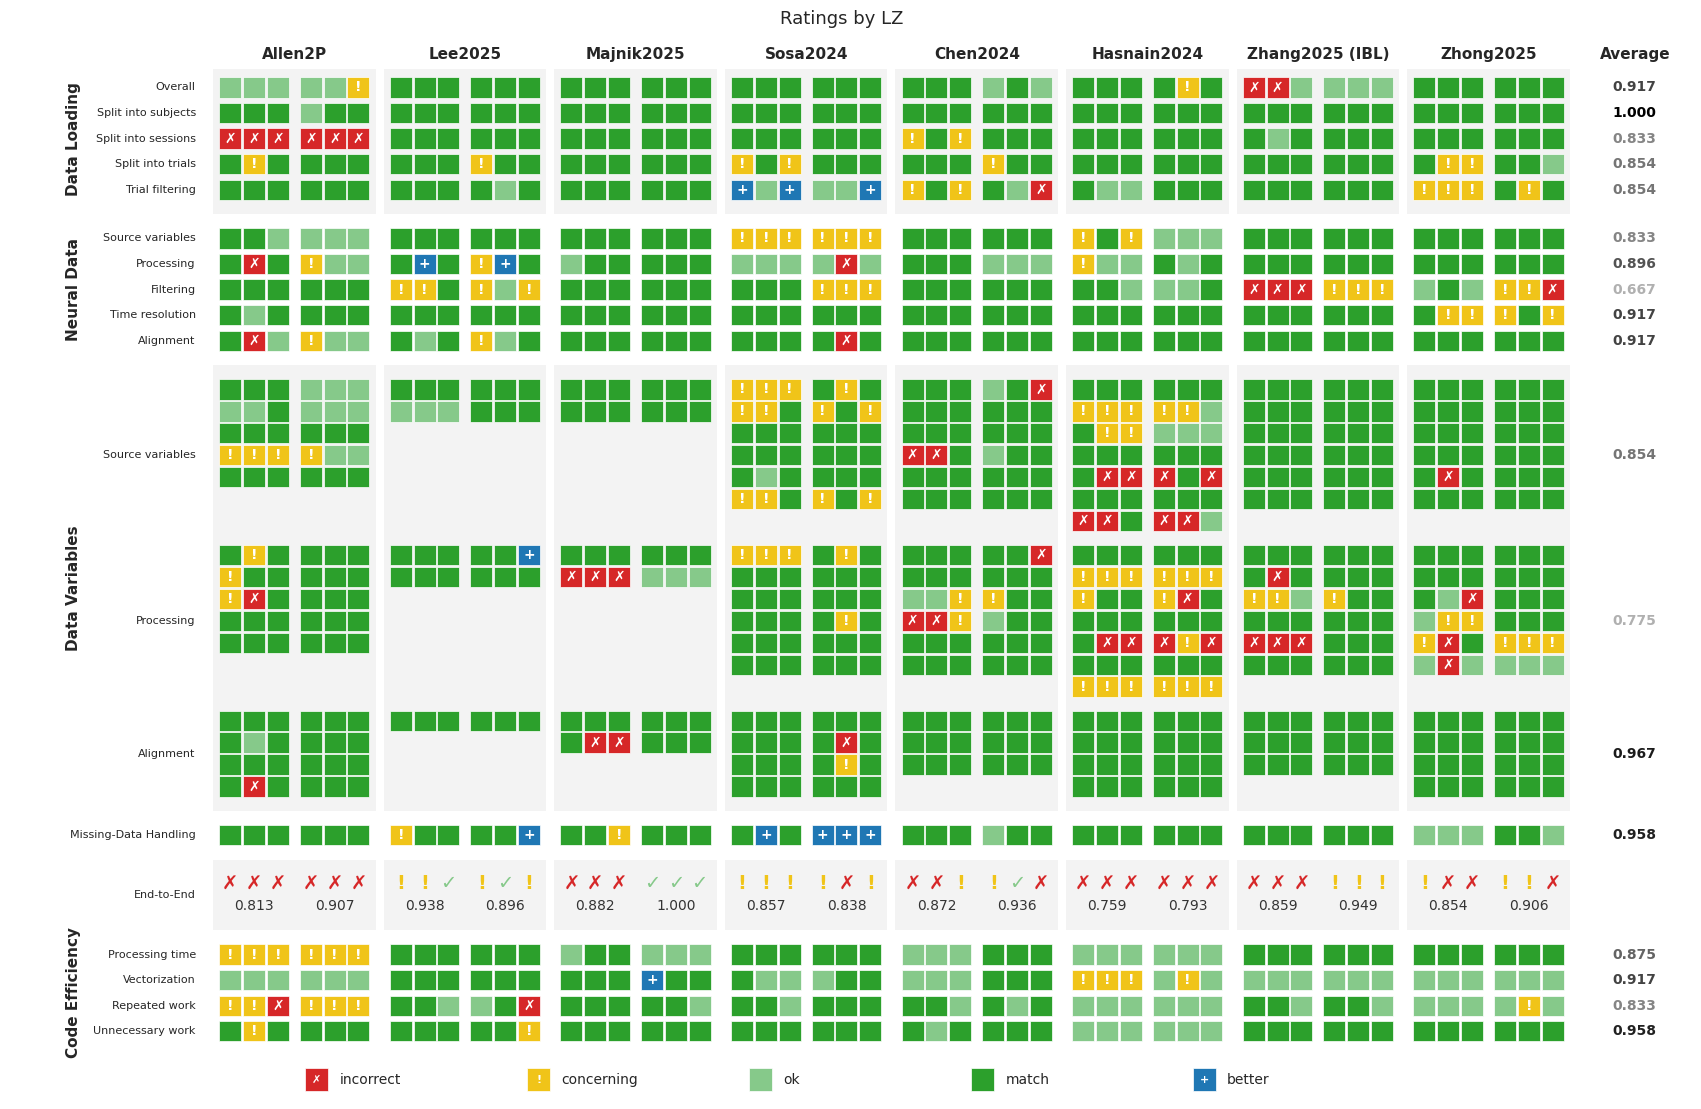

In [6]:
fig, _ = summary_table(ratings, rater="LZ", exclude_variables=EXCLUDE_VARS)
# fig.savefig('./Rating_LZ.pdf', bbox_inches='tight', dpi=300)
plt.show()

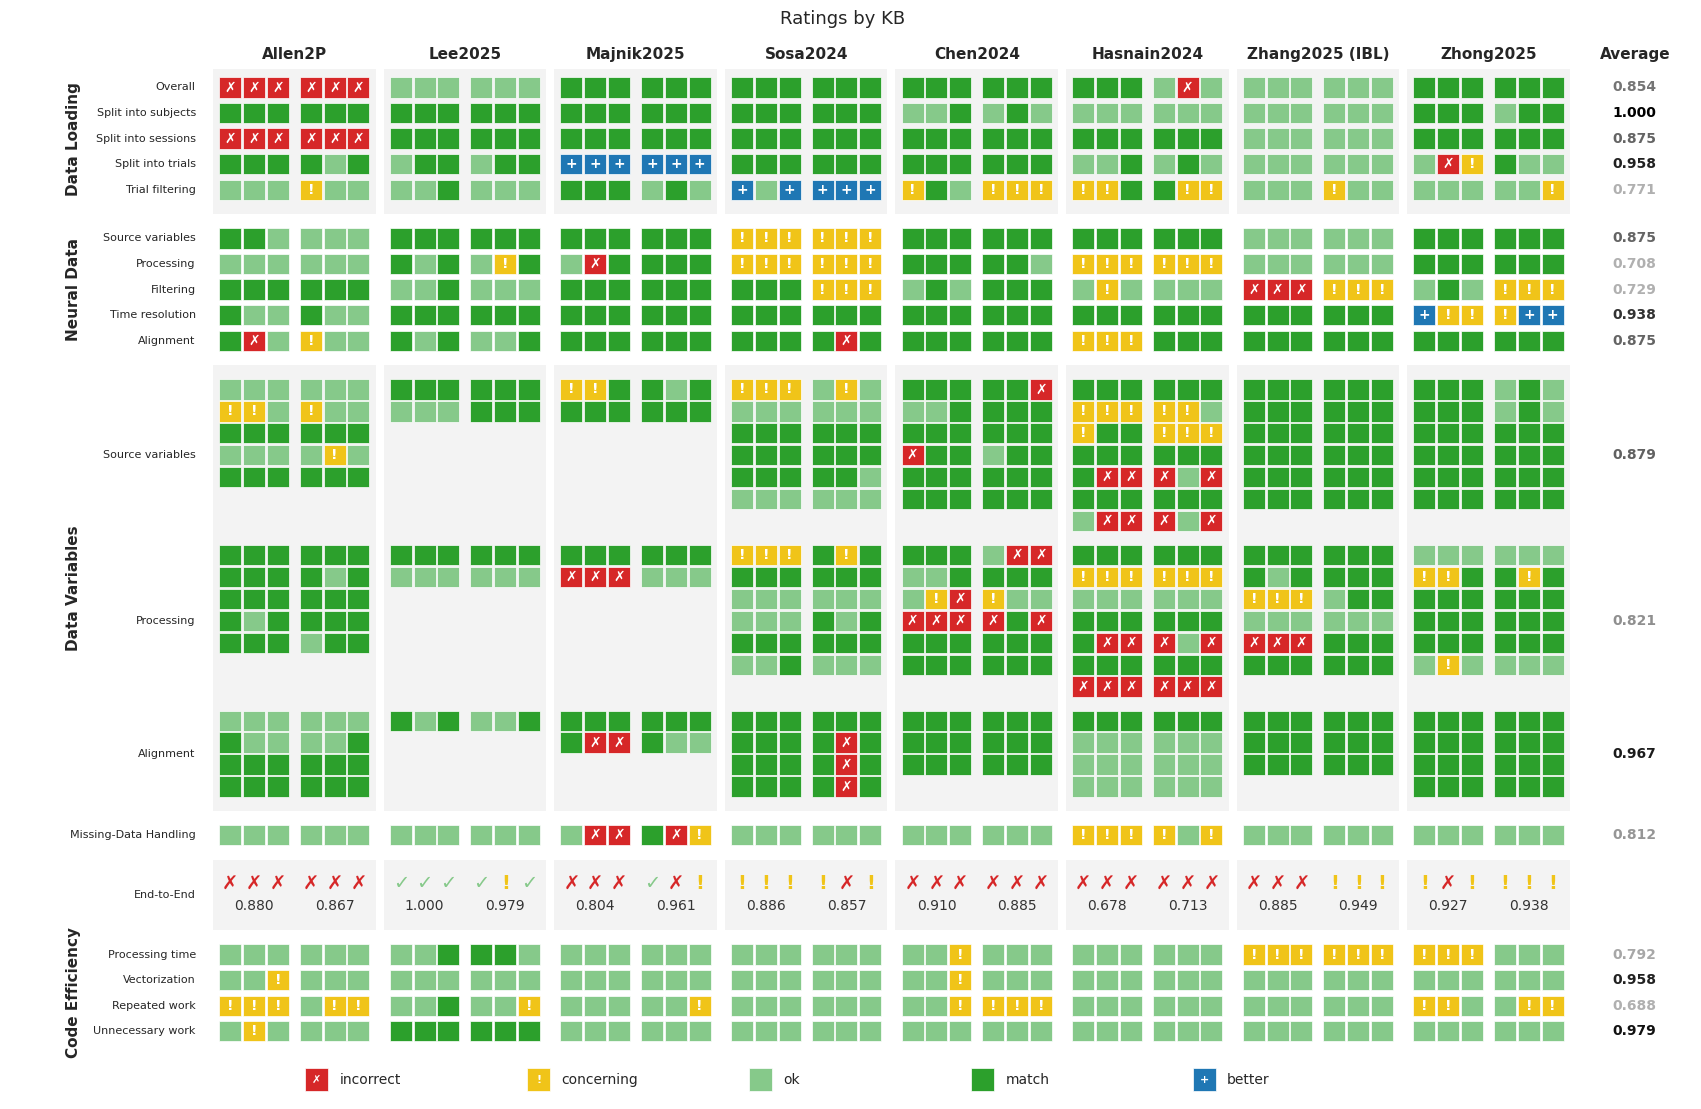

In [7]:
fig, _ = summary_table(ratings, rater="KB", exclude_variables=EXCLUDE_VARS)
# fig.savefig('./Rating_KB.pdf', bbox_inches='tight', dpi=300)
plt.show()

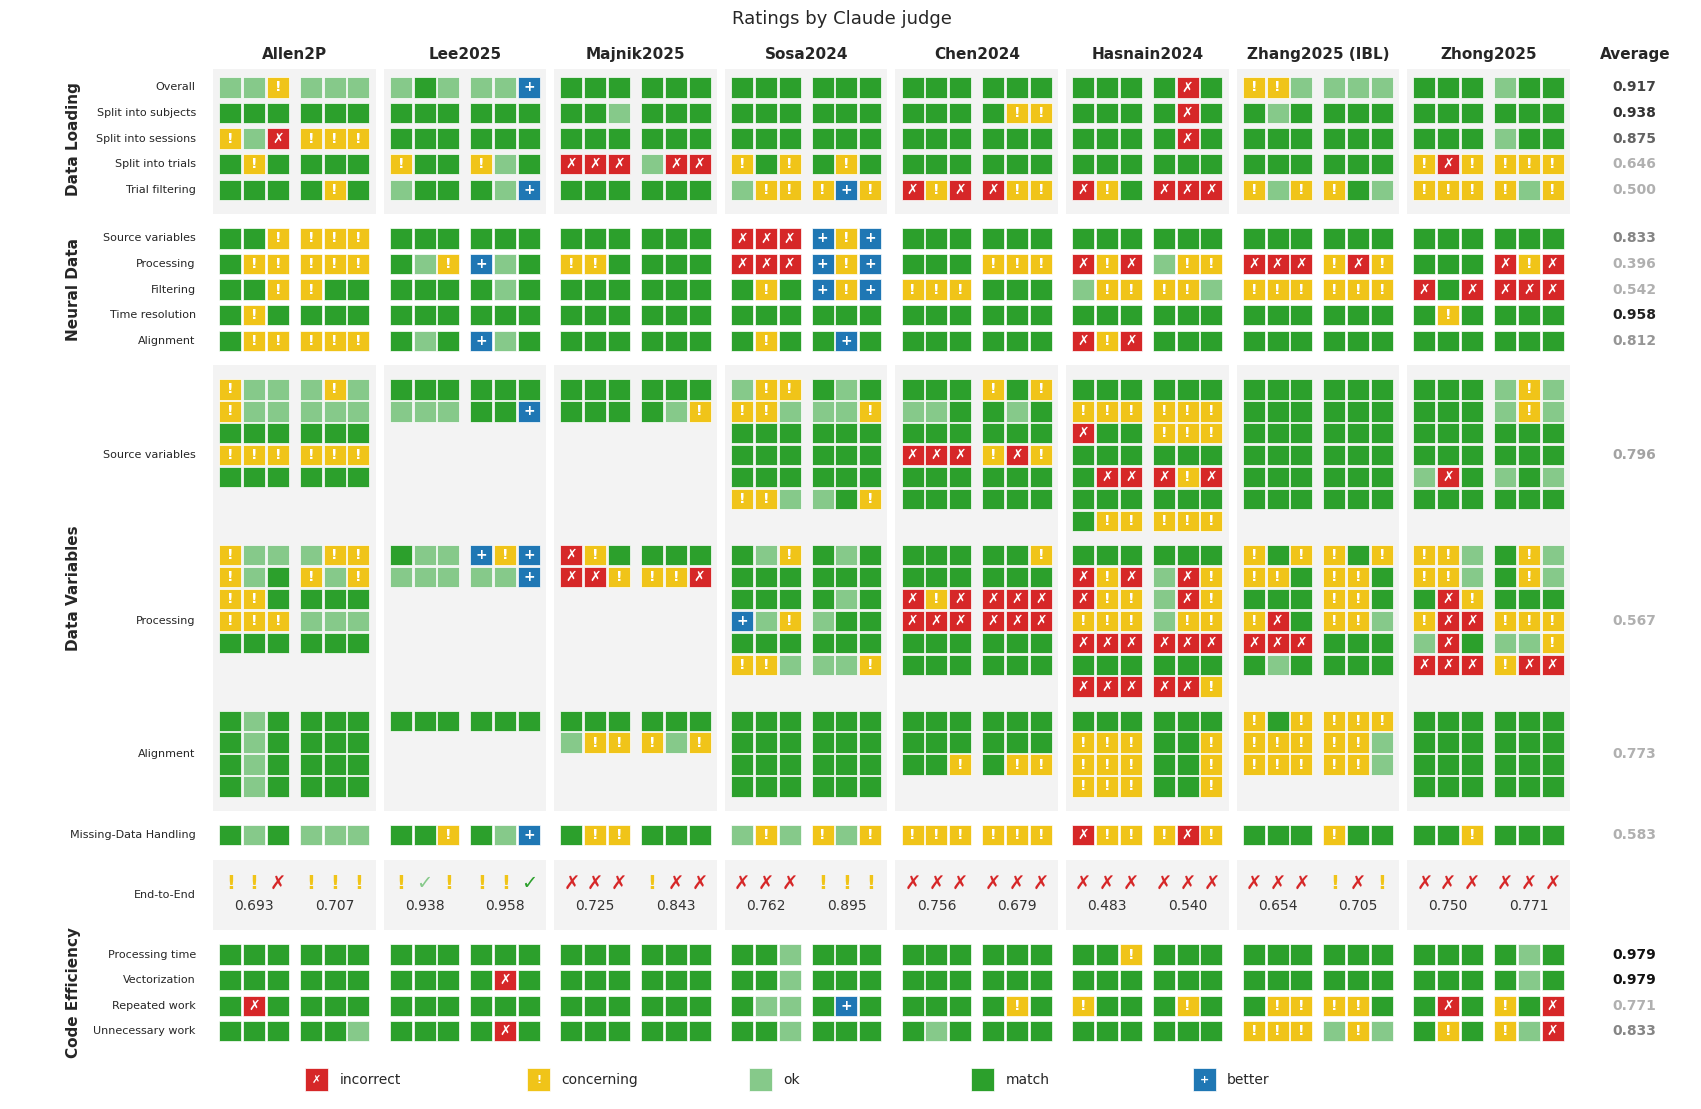

In [8]:
fig, _ = summary_table(ratings, rater="claude", exclude_variables=EXCLUDE_VARS)
# fig.savefig('./Rating_Claude.pdf', bbox_inches='tight', dpi=300)
plt.show()

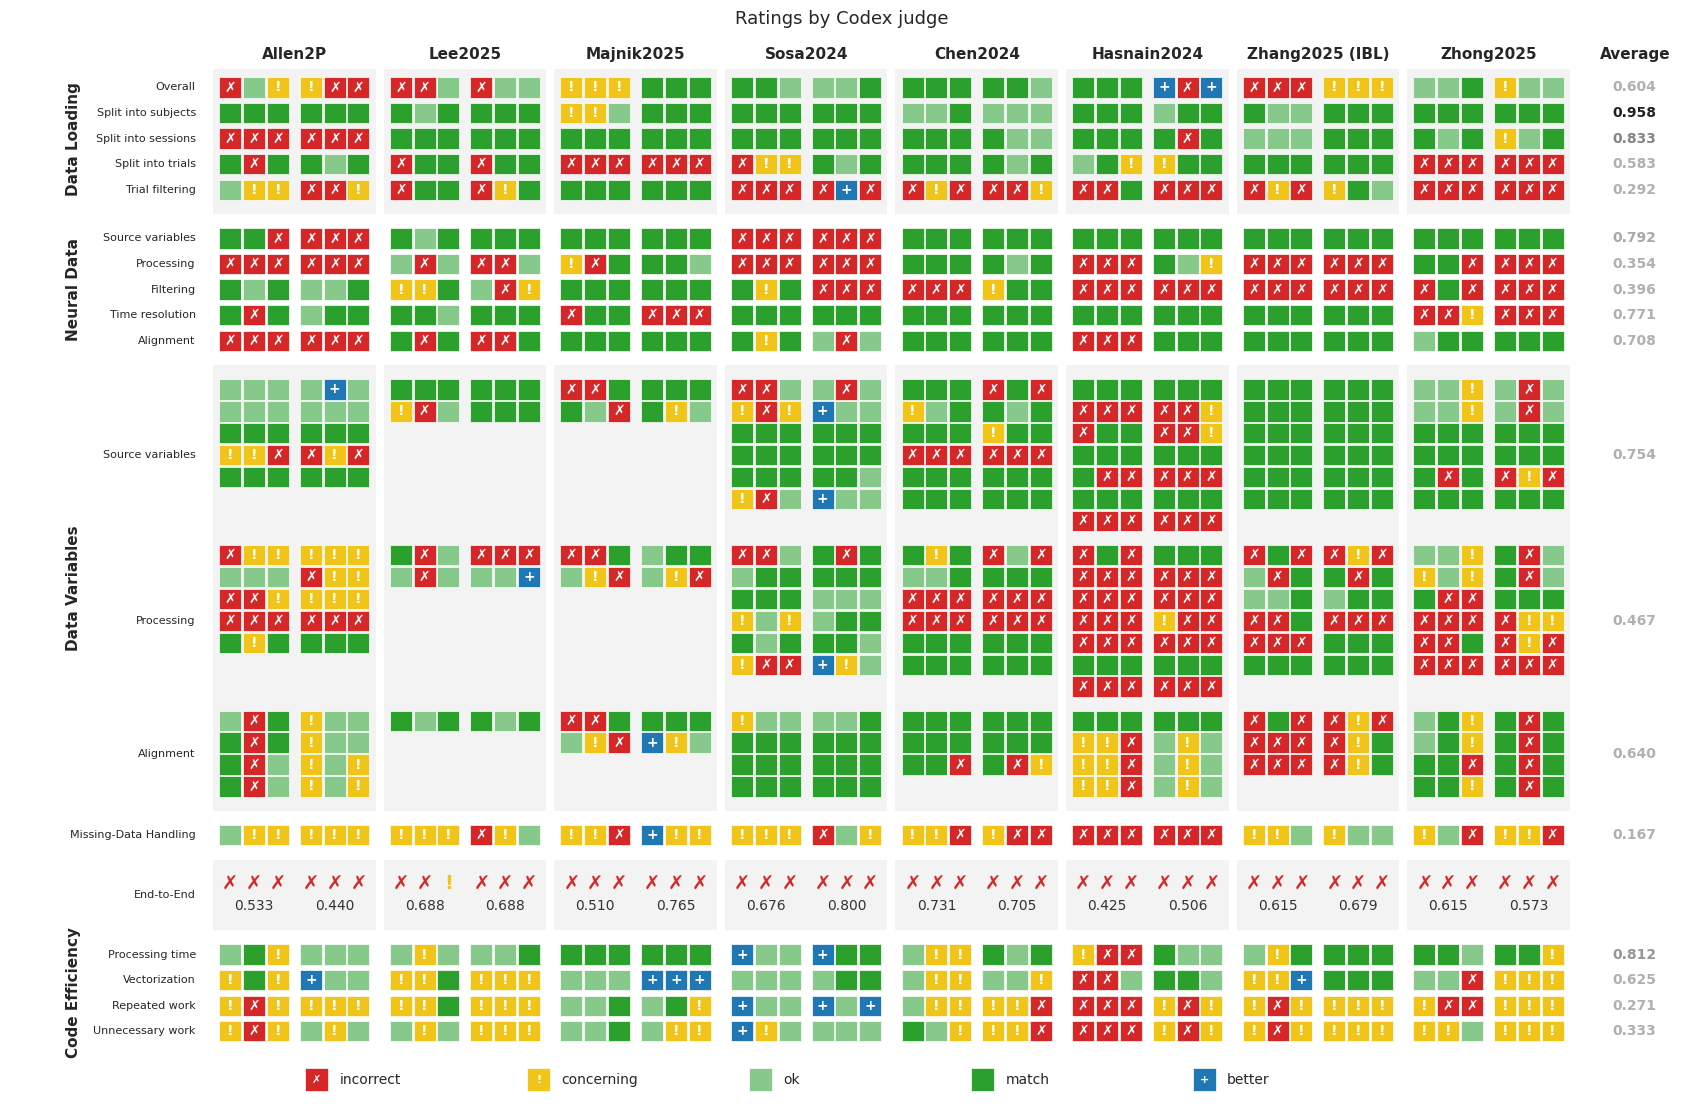

In [9]:
fig, _ = summary_table(ratings, rater="codex", exclude_variables=EXCLUDE_VARS)
# fig.savefig('./Rating_Codex.pdf', bbox_inches='tight', dpi=300)
plt.show()

## 3. Agreement between raters

Two measures per pair, over the rows where both rated:

| measure | reads as |
|---|---|
| `pearson` | linear agreement, treating -2..2 as an interval scale |
| `kappa` | Cohen's kappa, linearly weighted — chance-corrected |

Read `kappa` first: it discounts the agreement that the skew toward "match"
buys for free. The **LZ-KB** row is the human-human ceiling the judge rows
should be compared against.

The first block is every pair anchored on a human rater, ending with the
unsupervised judges against LZ — what withholding the reference solution
costs against the human reference. The second block is judge against judge:
the two judges against each other, and each judge against its own
unsupervised run, i.e. how much the reference solution changed its mind at all.

`process_only` throughout — the Code Efficiency block is excluded from
every table and figure below.

The last row is the null: LZ against a shuffled copy of LZ. Both measures
should sit at ~0 by construction — that is the floor.

In [10]:
# Two blocks: every pair anchored on a human rater, then the judge-against-judge
# pairs — the two judges against each other, and each judge against its own run
# without the reference solution.
HUMAN_PAIRS = [("LZ", "KB"),
               ("LZ", "claude"), ("LZ", "codex"),
               ("KB", "claude"), ("KB", "codex"),
               ("LZ", "claude_unsup"), ("LZ", "codex_unsup")]
JUDGE_PAIRS = [("claude", "codex"),
               ("claude", "claude_unsup"), ("codex", "codex_unsup")]

agree = pd.concat(
    [agreement.pairwise(process_only, pairs=HUMAN_PAIRS + JUDGE_PAIRS),
     agreement.pairwise(process_only, pairs=[("LZ", "LZ_null")])],
    ignore_index=True)
display.agreement(agree)

Rater A,Rater B,Pearson r,Cohen's κ
Human #1,Human #2,0.607,0.473
Human #1,Claude,0.473,0.373
Human #1,Codex,0.455,0.274
Human #2,Claude,0.501,0.422
Human #2,Codex,0.502,0.358
Human #1,Claude Unsup,0.239,0.193
Human #1,Codex Unsup,0.286,0.239
Claude,Codex,0.726,0.563
Claude,Claude Unsup,0.263,0.175
Codex,Codex Unsup,0.455,0.328


In [11]:
print(display.agreement_latex(
    agree, caption="Agreement between raters on the correctness questions.",
    label="tab:rater-agreement"))

\begin{table}
\caption{Agreement between raters on the correctness questions.}
\label{tab:rater-agreement}
\begin{tabular}{llrr}
\toprule
Rater A & Rater B & Pearson r & Cohen's $\kappa$ \\
\midrule
Human \#1 & Human \#2 & 0.607 & 0.473 \\
Human \#1 & Claude & 0.473 & 0.373 \\
Human \#1 & Codex & 0.455 & 0.274 \\
Human \#2 & Claude & 0.501 & 0.422 \\
Human \#2 & Codex & 0.502 & 0.358 \\
Human \#1 & Claude Unsup & 0.239 & 0.193 \\
Human \#1 & Codex Unsup & 0.286 & 0.239 \\
Claude & Codex & 0.726 & 0.563 \\
Claude & Claude Unsup & 0.263 & 0.175 \\
Codex & Codex Unsup & 0.455 & 0.328 \\
Human \#1 & Human Null & -0.015 & -0.013 \\
\bottomrule
\end{tabular}
\end{table}



The same numbers as a matrix — every pair at once, Pearson above the
diagonal and Cohen's kappa below, so a cell and its mirror image are the two
readings of one pair.

In [12]:
print(display.agreement_matrix_latex(
    process_only,
    caption=("Pairwise agreement between raters on the correctness questions. "
             "Above the diagonal: Pearson $r$. Below: linearly weighted Cohen's "
             "$\\kappa$, which discounts the agreement the skew toward "
             "\\emph{match} gives for free. Evaluators \\#1 and \\#2 are the two "
             "human raters; \\emph{Unsup} judges did not see the reference "
             "solution."),
    label="tab:rater-agreement-matrix"))

% requires \usepackage{booktabs}
\begin{table}[!h]
\centering
\setlength{\tabcolsep}{6pt}
\begin{tabular}{lcccccc}
\toprule
 & (1) & (2) & (3) & (4) & (5) & (6) \\
\midrule
(1) Evaluator \#1 & --- & 0.607 & 0.473 & 0.455 & 0.239 & 0.286 \\
(2) Evaluator \#2 & 0.473 & --- & 0.501 & 0.502 & 0.180 & 0.253 \\
(3) Claude & 0.373 & 0.422 & --- & 0.726 & 0.263 & 0.345 \\
(4) Codex & 0.274 & 0.358 & 0.563 & --- & 0.255 & 0.455 \\
(5) Claude Unsup & 0.193 & 0.120 & 0.175 & 0.114 & --- & 0.402 \\
(6) Codex Unsup & 0.239 & 0.210 & 0.302 & 0.328 & 0.292 & --- \\
\bottomrule
\end{tabular}
\vspace{5pt}
\caption{Pairwise agreement between raters on the correctness questions. Above the diagonal: Pearson $r$. Below: linearly weighted Cohen's $\kappa$, which discounts the agreement the skew toward \emph{match} gives for free. Evaluators \#1 and \#2 are the two human raters; \emph{Unsup} judges did not see the reference solution.}
\label{tab:rater-agreement-matrix}
\end{table}


### By dataset

Check if there are differences between dataset

In [13]:
# Every pair is anchored on LZ, the reference, plus claude-vs-codex to
# show the two judges against each other. KB-vs-judge pairs are in the
# overall table above; six columns per dataset is too wide to read.
PAIRS = [("LZ", "KB"), ("LZ", "claude"), ("LZ", "codex"),
         ("claude", "codex")]

by_ds = agreement.pairwise(process_only, by="dataset", pairs=PAIRS)
by_ds.pivot(index="dataset", columns=["rater_a", "rater_b"], values="kappa").round(3)

rater_a         LZ               claude
rater_b         KB claude  codex  codex
dataset                                
allen2p      0.450  0.492  0.258  0.363
chen2024     0.503  0.377  0.299  0.764
hasnain2024  0.434  0.339  0.273  0.685
lee2025      0.295  0.199  0.219  0.289
majnik2025   0.558  0.388  0.164  0.462
sosa2024     0.520  0.312  0.267  0.509
zhang2025    0.493  0.285  0.272  0.662
zhong2025    0.376  0.410  0.284  0.518

### Where a rater drifts

The matrix behind the agreement numbers: rows are the rater's rating, columns
the reference's. The diagonal is agreement; the shape of what falls off it
separates a rater who is *harsher* than the reference from one who is merely
noisy — two failure modes a single κ reports identically.

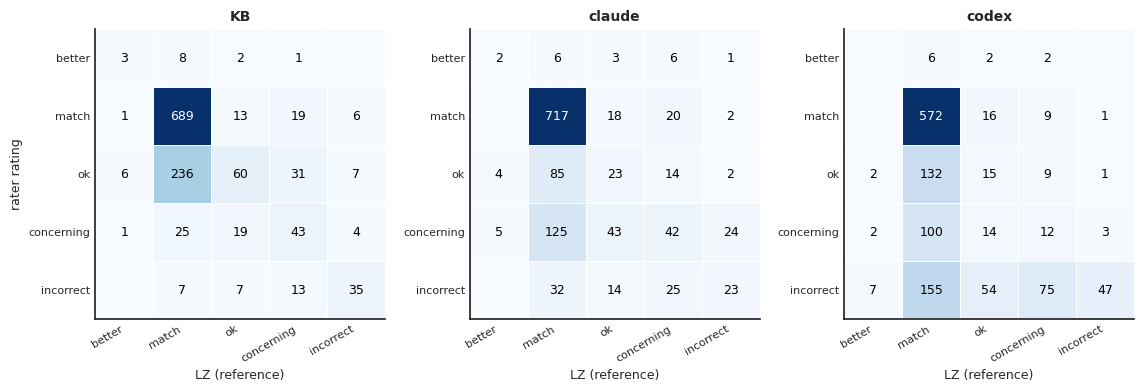

In [14]:
fig, _ = plots.confusion_grid(process_only, ("KB", "claude", "codex"), truth="LZ")
plt.show()

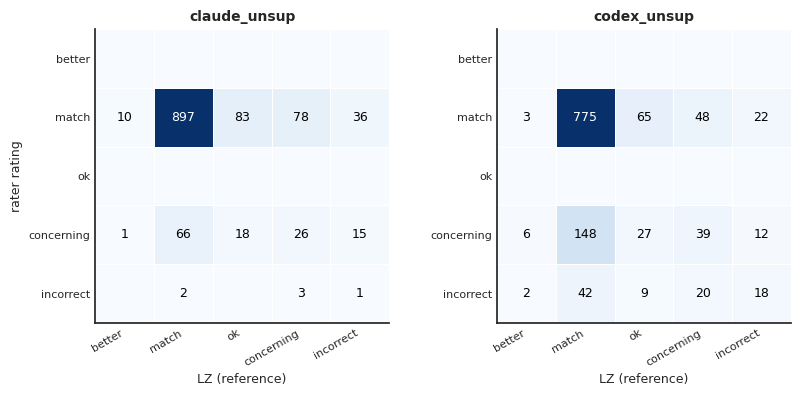

In [15]:
fig, _ = plots.confusion_grid(process_only, ("claude_unsup", "codex_unsup"), truth="LZ")
plt.show()

## 4. Binary accuracy — catching mistakes

Collapse the five levels into a two-level decision, with **incorrect as the
positive class**, and treat LZ as truth:

* `incorrect` = rating <= -1 (concerning / incorrect) — the event to detect
* `correct` = rating >= 0 (ok / match / better)

So the numbers say how well each rater catches the mistakes LZ found:

Both judge runs are here: `Claude` / `Codex` saw the reference solution,
`Claude Unsup` / `Codex Unsup` did not. `Combined` is the two supervised
judges made to agree — a mistake only where *both* call one, correct as soon
as either says so — which trades recall for the precision they individually
lack. Same `process_only` frame as section 3, so the two sections describe
the same questions.

`accuracy` is deliberately not the headline — mistakes are rare, so a rater
that flags nothing scores well on it. The `LZ_null` row is the floor.

In [16]:
# `combined` is the two supervised judges required to agree: on the -2..2
# scale, "incorrect only if both say incorrect" is their element-wise maximum.
PREDICTORS = ("KB", "claude", "codex", "combined",
              "claude_unsup", "codex_unsup", "LZ_null")
bin_all = binary.table(add_combined(process_only), "LZ", PREDICTORS)
display.binary(bin_all, accuracy=True)

Rater,Accuracy,Balanced Acc,Recall,Precision,F1,TP,FP,FN,TN
Human #2,0.900,0.771,0.597,0.617,0.607,95,59,64,1018
Claude,0.786,0.757,0.717,0.342,0.463,114,219,45,858
Codex,0.714,0.777,0.862,0.292,0.436,137,332,22,745
Combined,0.803,0.748,0.673,0.359,0.468,107,191,52,886
Claude Unsup,0.837,0.601,0.283,0.341,0.309,45,87,114,990
Codex Unsup,0.754,0.671,0.560,0.276,0.369,89,234,70,843
Human Null,0.773,0.495,0.119,0.119,0.119,19,140,140,937


In [17]:
# The paper's table: rows grouped by what the rater had in front of it, and
# `d'` alongside balanced accuracy. `LZ_null` has no row here — it is a floor
# for reading the numbers, not a result.
print(display.judge_latex(
    bin_all,
    caption=("Judging the conversions. Each row is one rater against the "
             "reference evaluator across all 8 datasets, with \\emph{incorrect} "
             "as the positive class. \\emph{Supervised} judges were given the "
             "reference solution; \\emph{unsupervised} judges were not; the "
             "second human evaluator worked from the same material as a "
             "supervised judge. \\emph{Combined} is the conjunction of the two "
             "supervised judges: a conversion step counts as incorrect only "
             "where both judges call it so."),
    label="tab:judge-accuracy"))

% requires \usepackage{booktabs, multirow}
\begin{table}[!h]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{l l rrrr ccc cc}
\toprule
& & \multicolumn{4}{c}{Counts} & \multicolumn{3}{c}{Catching Mistakes} & \multicolumn{2}{c}{Discriminability} \\
\cmidrule(lr){3-6} \cmidrule(lr){7-9} \cmidrule(lr){10-11}
Setup & Rater & TP & FP & FN & TN & F1 & Recall & Prec. & Bal.\ Acc. & $d'$ \\
\midrule
\multirow{1}{*}{Human} & Second evaluator & 95 & 59 & 64 & 1018 & 0.607 & 0.597 & 0.617 & 0.771 & 1.842 \\
\midrule
\multirow{3}{*}{Supervised} & Claude & 114 & 219 & 45 & 858 & 0.463 & 0.717 & 0.342 & 0.757 & 1.399 \\
 & Codex & 137 & 332 & 22 & 745 & 0.436 & 0.862 & 0.292 & 0.777 & 1.578 \\
 & Combined & 107 & 191 & 52 & 886 & 0.468 & 0.673 & 0.359 & 0.748 & 1.369 \\
\midrule
\multirow{2}{*}{Unsupervised} & Claude & 45 & 87 & 114 & 990 & 0.309 & 0.283 & 0.341 & 0.601 & 0.827 \\
 & Codex & 89 & 234 & 70 & 843 & 0.369 & 0.560 & 0.276 & 0.671 & 0.930 \\
\bottomrule
\end{tabular}
\caption{Judg

### The two human evaluators

LZ and KB on the rows both rated, at the two resolutions the sections above
use: the five levels, and the `correct` / `incorrect` split section 4 scores
every rater on. The right panel is KB's row of the table above, drawn as a
matrix.

The two per-category proportions are conditioned on LZ, so they are the shares
of LZ's `correct` and `incorrect` calls that KB called the same way.


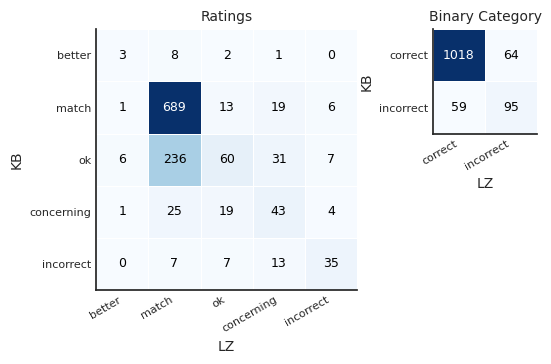

n = 1236 rows both rated | pearson r = 0.607 | weighted kappa = 0.473
collapsed: KB agrees on 0.945 of the 1077 LZ called correct and 0.597 of the 159 LZ called incorrect (0.900 overall)


In [18]:
fig, _ = plots.rater_confusion(process_only, "LZ", "KB")
plt.show()

pair = agreement.pair_stats(process_only, "LZ", "KB")
cat = binary.category_agreement(process_only, "LZ", "KB")
print(f"n = {pair['n']} rows both rated | "
      f"pearson r = {pair['pearson']:.3f} | "
      f"weighted kappa = {pair['kappa']:.3f}")
print(f"collapsed: KB agrees on {cat['correct']:.3f} of the {cat['n_correct']} "
      f"LZ called correct and {cat['incorrect']:.3f} of the "
      f"{cat['n_incorrect']} LZ called incorrect ({cat['overall']:.3f} overall)")

# fig.savefig('./confusion_matrix.pdf', bbox_inches='tight', dpi=300)


### Judge on its own agent vs the other agent

Does a judge go easier on the agent that shares its model? Split the same
counts by whose trials are being scored: `Judge` is the rater, `Target` the
agent that produced the trial, and the two rows where they differ are the
cross-model comparison (shaded in the LaTeX version).

In [19]:
by_agent = binary.table(process_only, "LZ",
                        ("claude", "codex", "claude_unsup", "codex_unsup"),
                        by="agent")
display.cross_judge(by_agent)

Family,Judge,Target,TP,FP,FN,TN,F1,Recall,Precision,Balanced Acc,d'
Supervised,Claude,Claude,74,106,20,418,0.540,0.787,0.411,0.792,1.618
Supervised,Claude,Codex,40,113,25,440,0.367,0.615,0.261,0.706,1.113
Supervised,Codex,Claude,82,165,12,359,0.481,0.872,0.332,0.779,1.600
Supervised,Codex,Codex,55,167,10,386,0.383,0.846,0.248,0.772,1.516
Unsupervised,Claude,Claude,27,48,67,476,0.320,0.287,0.360,0.598,0.771
Unsupervised,Claude,Codex,18,39,47,514,0.295,0.277,0.316,0.603,0.884
Unsupervised,Codex,Claude,50,120,44,404,0.379,0.532,0.294,0.651,0.820
Unsupervised,Codex,Codex,39,114,26,439,0.358,0.600,0.255,0.697,1.067


In [20]:
print(display.cross_judge_latex(
    by_agent,
    caption=("Per-judge agreement broken down by which agent's trials are being "
             "scored -- within-judge rows (Judge $=$ Target) vs cross-judge rows "
             "(Judge $\\neq$ Target, grey rows). The definitions are the same as "
             "Table~\\ref{tab:judge-accuracy}: TP = judge correctly flags a "
             "mistake, FP = false alarm, FN = missed mistake, TN = correctly "
             "accepted. F1, recall and precision are the mistake-catching view; "
             "Bal.\\ Acc.\\ and $d'$ summarize the judge's overall "
             "evaluation performance. Sample size: $n{=}{n}$ question-trial rows "
             "per pairing, across all 8 datasets."),
    label="judge_agreement_cross"))

% requires \usepackage{booktabs, multirow} and xcolor with a rowgray color
\newcommand{\crossrow}{\cellcolor{rowgray}}

\begin{table}[!h]
\centering
\setlength{\tabcolsep}{4pt}
\begin{tabular}{l l l rrrr ccc cc}
\toprule
& & & \multicolumn{4}{c}{Counts} & \multicolumn{3}{c}{Catching Mistakes} & \multicolumn{2}{c}{Discriminability} \\
\cmidrule(lr){4-7} \cmidrule(lr){8-10} \cmidrule(lr){11-12}
Family & Judge & Target & TP & FP & FN & TN & F1 & Recall & Prec. & Bal.\ Acc. & $d'$ \\
\midrule
\multirow{4}{*}{Supervised} & Claude & Claude & 74 & 106 & 20 & 418 & 0.540 & 0.787 & 0.411 & 0.792 & 1.618 \\
 & \crossrow Claude & \crossrow Codex & \crossrow 40 & \crossrow 113 & \crossrow 25 & \crossrow 440 & \crossrow 0.367 & \crossrow 0.615 & \crossrow 0.261 & \crossrow 0.706 & \crossrow 1.113 \\
 & \crossrow Codex & \crossrow Claude & \crossrow 82 & \crossrow 165 & \crossrow 12 & \crossrow 359 & \crossrow 0.481 & \crossrow 0.872 & \crossrow 0.332 & \crossrow 0.779 & \crossrow 1.600 \\
 & Codex 

### Scoring a whole trial

Whether a judge could stand in for a human when *scoring* a run, which is a
weaker requirement than agreeing question by question. One point per trial (8
datasets x 6 runs), scored the way section 5 scores them: the proportion of
that trial's questions rated at least `ok`. Each rater scores on the questions
it answered.

KB against LZ is the human-human ceiling to read the judge against. The dashed
line is equality, not a fit, so a point below it is a harsher score than LZ
gave the same run.


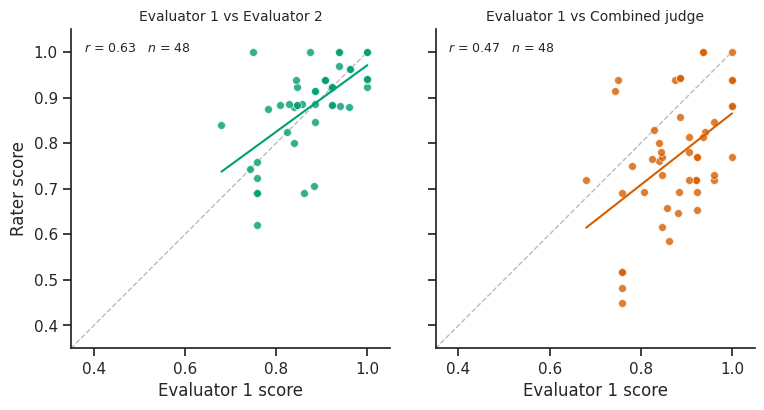

In [21]:
fig, _, score_stats = plots.score_scatter(add_combined(process_only),
                                         ("KB", "combined"))
plt.show()
# fig.savefig('./score_correlation.pdf', bbox_inches='tight', dpi=300)

## 5. Agent performance

The first four sections ask how much the raters agree. This one uses the
reference rater's ratings to ask what they say about the *agents*.

### Does the source format make a difference?

One point per trial: the fraction of that trial's questions rated at least
`ok`, with a bar at each agent's mean. Datasets are ordered so that the ones
sharing a raw-data format sit together.

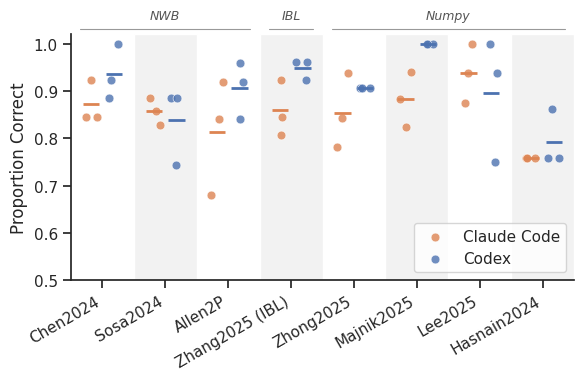

In [ ]:
fig, _ = plots.format_scatter(ratings, rater="LZ")
# fig.savefig('./score_compare_dataset.pdf', bbox_inches='tight', dpi=300)
plt.show()

### What ratings did each agent earn?

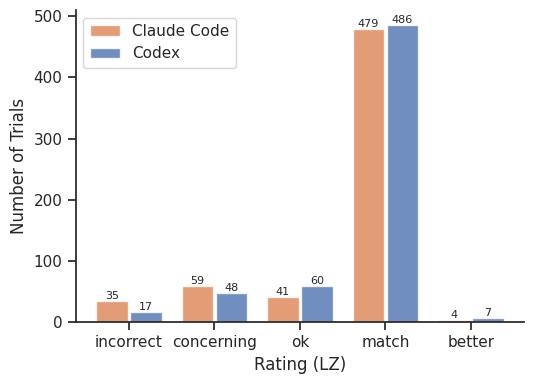

In [ ]:
fig, _ = plots.rating_levels(process_only, rater="LZ")
# fig.savefig('./score_compare_agents.pdf', bbox_inches='tight', dpi=300)
plt.show()

### How repeatable is a trial?

Per question, the worst of an agent's three trials minus the best. 0 means
all three agreed exactly; -3 means one run was rated three levels below
another on the same question.

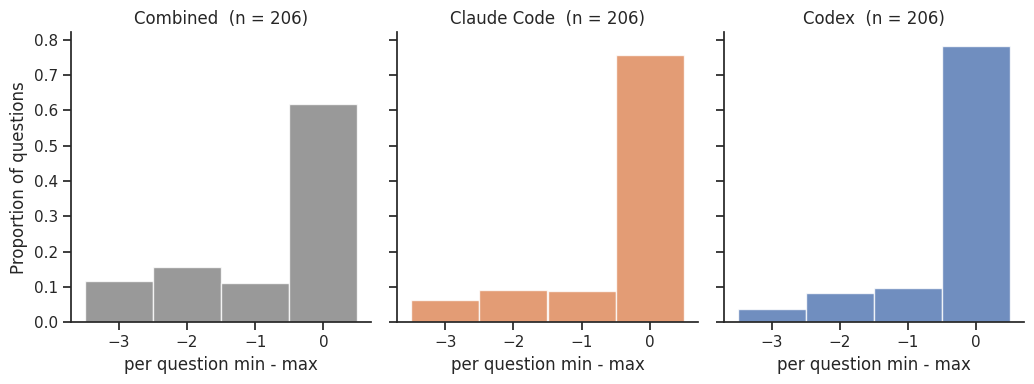

In [24]:
fig, _ = plots.trial_variability(process_only, rater="LZ", kind="spread")
plt.show()

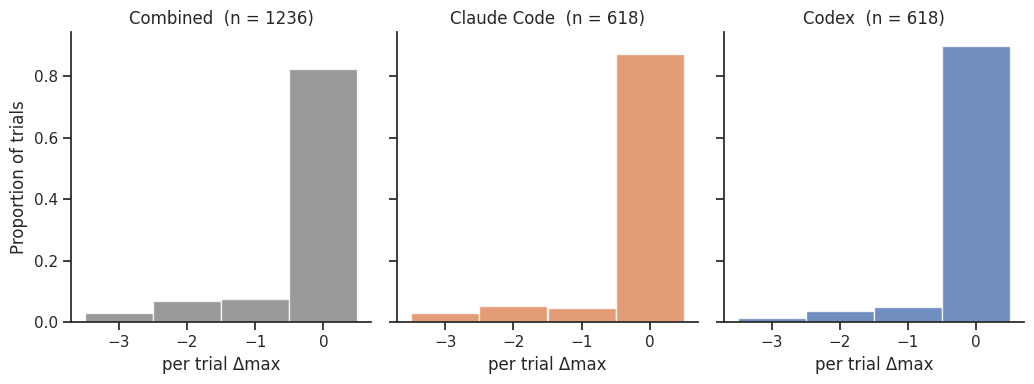

In [25]:
fig, _ = plots.trial_variability(process_only, rater="LZ", kind="delta")
plt.show()

## 6. Difference categories

Each `eval/<dataset>/report.md` has a "Difference categories" column on the per-question table where I tag the *kind* of disagreement between trials with entries like `` `VARNAME=6` `` or `` `MISC=1` ``. Only entries with the `LABEL=N` form are counted (bare labels like `` `MISC` `` or `` `SEMANTIC` `` are skipped — they're informal). The total per label is the sum of the `N` values across all 8 reports.

The tags are the one part of the evaluation that judges the *kind* of
mistake rather than its severity, so they are hand-written and live only
in the reports. The case studies in `case_studies/examples.ipynb` walk through one
failure per category.

In [26]:
summary = categories.difference_categories()
summary

,allen2p,lee2025,majnik2025,sosa2024,chen2024,hasnain2024,zhang2025,zhong2025,TOTAL
PROCESS,0,2,2,6,5,12,0,4,31
ASSUME,0,5,0,11,2,4,8,0,30
FILTER,1,4,0,3,3,0,6,7,24
VARNAME,6,0,0,0,2,4,0,4,16
MISC,5,0,3,0,0,1,0,6,15
TIME_RES,6,0,0,2,0,0,2,0,10
TOTAL,18,11,5,22,12,21,16,21,126


#### Category definitions

- **FILTER** — Inconsistent or unjustified choices when **filtering data** (trials, neurons/units, sessions). Covers both *which* criterion to apply (spike-rate cutoff, ISI-violation threshold, behavioral exclusion rule, project-code filter) and *what value* to use, especially when the paper does not explicitly prescribe one. Also includes deciding what data to ignore given the context of the paper's analysis.
- **TIME_RES** — Inconsistent choices about **temporal representation**: time-bin width, output sampling rate, whether to upsample / downsample / leave at native rate, and how to align streams that arrive at different rates.
- **PROCESS** — Mistakes that show up when the requested output variable requires **non-trivial processing** from the raw data — e.g., combining multiple raw streams, computing a derived quantity (velocity from position, motion energy from frames, distance to landmark), unit conversion, event detection. Failures are usually that the agent picked an incorrect or sub-optimal procedure, not that they failed to find the data.
- **ASSUME** — Wrong **assumptions about what the data contains or means**, made without checking the assumption against the data itself. Sources include skimming the paper/methods and over-interpreting; defaulting to a "common-case" convention that doesn't apply to this dataset; treating a sign convention, coordinate system, or unit as given. Distinguished from PROCESS in that the error is a *belief* about the data, not a faulty *procedure*.
- **VARNAME** — A special case of **ASSUME** where the agent inferred a variable's meaning purely from its name in the raw data without verifying against actual values or upstream code (e.g., a column called `position` that actually stores wheel-encoder ticks; an `image_id` field whose integer index does not map directly to image identity).
- **MISC** — Mistakes that don't fit the above categories. Used sparingly.

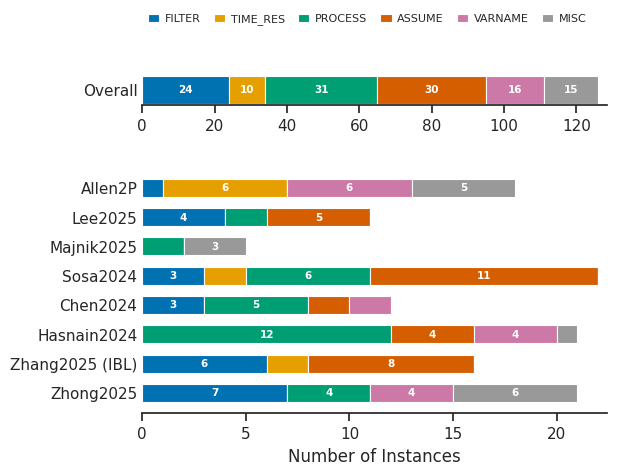

In [27]:
fig, _ = plots.category_breakdown(summary)
plt.show()

### How repeatable is a trial?

Per question, the worst of an agent's three trials minus the best. 0 means
all three agreed exactly; -3 means one run was rated three levels below
another on the same question.

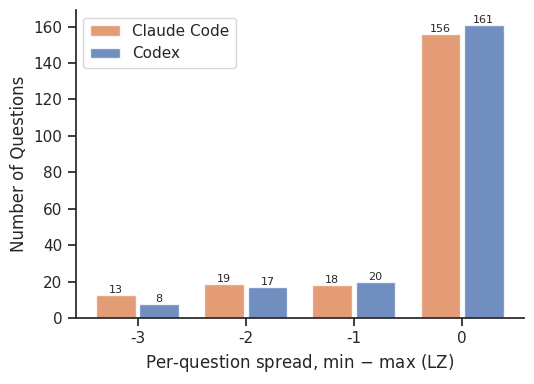

In [28]:
fig, _ = plots.spread_bars(process_only, rater="LZ")
plt.show()

# Ratings across run conditions

Six conditions — `(agent, prompt)` — judged by the two supervised LLM judges. Only
Claude Code and Codex at the full prompt have human ratings; the other four
(minimal prompt, and the two Terminus harnesses) have none.

No truth column, so nothing here is an accuracy. The judges' precision against
the human evaluator is 0.24–0.31, so every condition's level is depressed by roughly
the same unknown amount: read differences between conditions, not levels. Rater
throughout is `combined` — a mistake only where both judges call one.

In [29]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

%load_ext autoreload
%autoreload 2

# Same house style as ratings_analysis.ipynb.
sns.set_theme(style="ticks", rc={"axes.spines.right": False,
                                "axes.spines.top": False})
mpl.rcParams["figure.dpi"] = 100
mpl.rcParams["savefig.dpi"] = 100
mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42

from ratings import (add_combined, agreement, conditions, drop_efficiency,
                     display, load_condition_ratings, plots)
from ratings import experiments
from ratings.experiments import (CONDITION_COLOR, CONDITION_LABEL,
                                 CONDITION_ORDER)

pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 120)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
# Read the supervised judge verdicts straight out of
# data-format-experiments/<task>/<agent>/<timestamp>_trial<N>/verifier/judge/,
# mapping each judge's own question numbering onto our references by content.
# On the two conditions `load_ratings()` also covers, this reproduces it cell for
# cell — `python3 -m ratings validate-conditions` is that check.
r = load_condition_ratings()

# Code Efficiency questions are performance advice rather than a check on
# whether the conversion is right, and are dropped exactly as next door.
# `combined` is the two judges' consensus.
process_only = add_combined(drop_efficiency(r.tidy))
scores = conditions.condition_scores(process_only, rater="combined")

print(r)
print(f"{len(r.tidy)} rows total, {len(process_only)} after dropping "
      f"{sorted(set(r.tidy.category) - set(process_only.category))} = "
      f"{process_only.drop_duplicates(['dataset', 'qid']).shape[0]} questions"
      f" x {len(r.conditions)} conditions x 3 trials")
print("skipped:", r.skipped)

ConditionRatings(8 datasets, 6 conditions, 4284 rows, claude=4283, codex=4284)
4284 rows total, 3708 after dropping ['Code Efficiency'] = 206 questions x 6 conditions x 3 trials
skipped: {'agents': ['claude-code-config_20260728-prompt_v5', 'claude-code-config_20260919', 'codex-config_20260728-prompt_v5', 'codex-config_20260919', 'terminus-gpt-config_20260728-prompt_v5', 'terminus-gpt-config_20260919', 'terminus-opus-config_20260728-prompt_v5', 'terminus-opus-config_20260919'], 'trials': ['zhang2025/codex/trial4']}


/tmp/ipykernel_69800/1381323605.py:6: UserWarning: zhang2025: judge files map different numbers of questions depending on the condition (29-30): {'claude-code/full': array([30]), 'claude-code/minimal': array([30, 29]), 'codex/full': array([30]), 'codex/minimal': array([30]), 'terminus-gpt/full': array([30]), 'terminus-opus/full': array([30])}. Arm comparisons for this dataset are not like-for-like.
  r = load_condition_ratings()


## 1. Across-judge consistency

Do the two judges still agree on the conditions nobody checked them against?

In [31]:
by_condition = agreement.pairwise(process_only, pairs=[("claude", "codex")], by="condition")
by_condition["condition"] = by_condition["condition"].map(CONDITION_LABEL)
display.agreement(by_condition)

condition,Rater A,Rater B,Pearson r,Cohen's κ
Claude Code (maximal),Claude,Codex,0.793,0.616
Claude Code (minimal),Claude,Codex,0.730,0.560
Codex (maximal),Claude,Codex,0.654,0.509
Codex (minimal),Claude,Codex,0.673,0.524
Terminus/GPT (maximal),Claude,Codex,0.696,0.590
Terminus/Opus (maximal),Claude,Codex,0.781,0.661


## 2. The harness

All four ran the full prompt, so the prompt qualifier is dropped from the
labels. Taken in pairs that share a model family, the comparison is the
scaffold alone:

| | agent harness | Terminus harness |
|---|---|---|
| Claude | Claude Code | Terminus/Opus |
| GPT | Codex | Terminus/GPT |

One point per trial; the bar is that condition's mean within the dataset.
Under the Overall boxes, mean ± SE over every point in the panel, so the ±
collapses trial and dataset noise together.

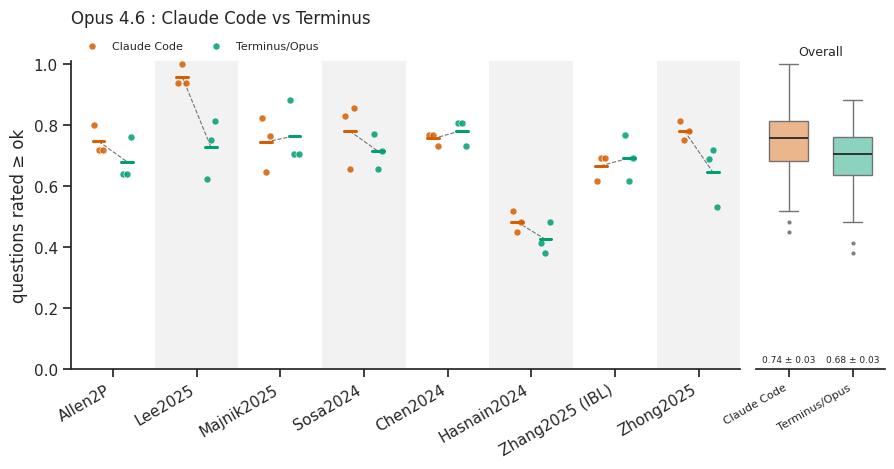

In [32]:
CLAUDE_PAIR = ("claude-code/full", "terminus-opus/full")
fig, _ = conditions.condition_scatter(scores, conditions=CLAUDE_PAIR, ylim=(0.0, 1.01),
                          title="Opus 4.6 : Claude Code vs Terminus")
plt.show()

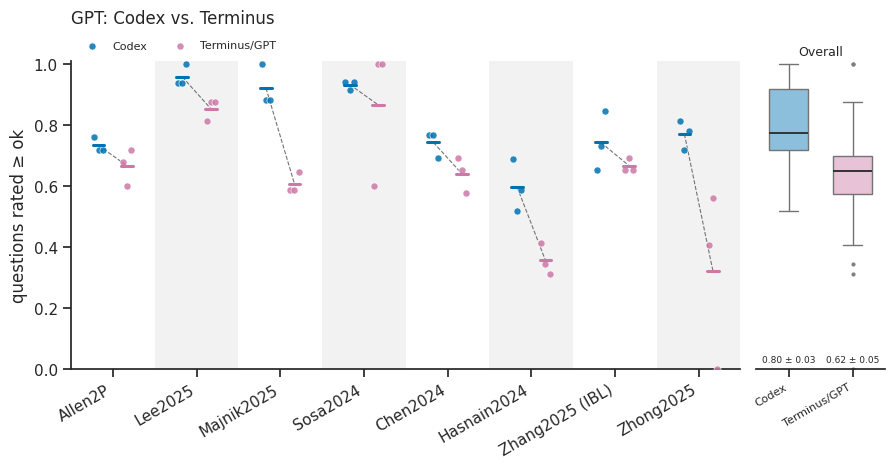

In [33]:
GPT_PAIR = ("codex/full", "terminus-gpt/full")
fig, _ = conditions.condition_scatter(scores, conditions=GPT_PAIR, ylim=(0.0, 1.01),
                          title="GPT: Codex vs. Terminus")
plt.show()

## 3. The prompt

Claude Code and Codex are the only agents that ran both, so this is paired
within-agent.

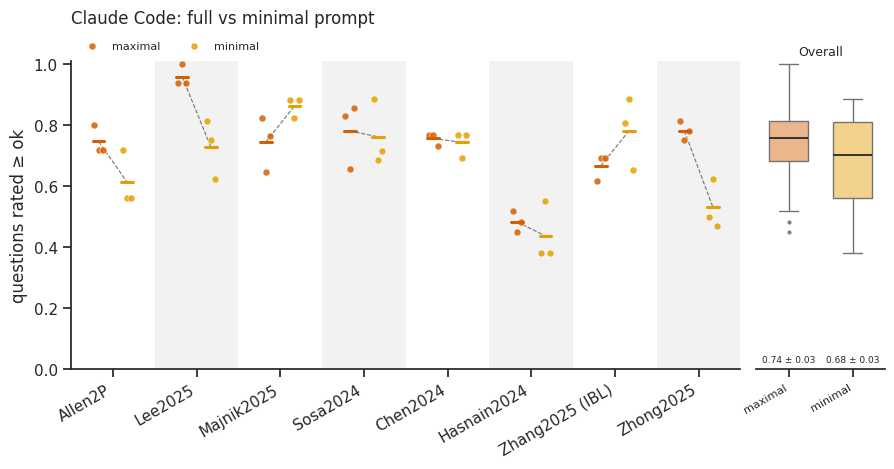

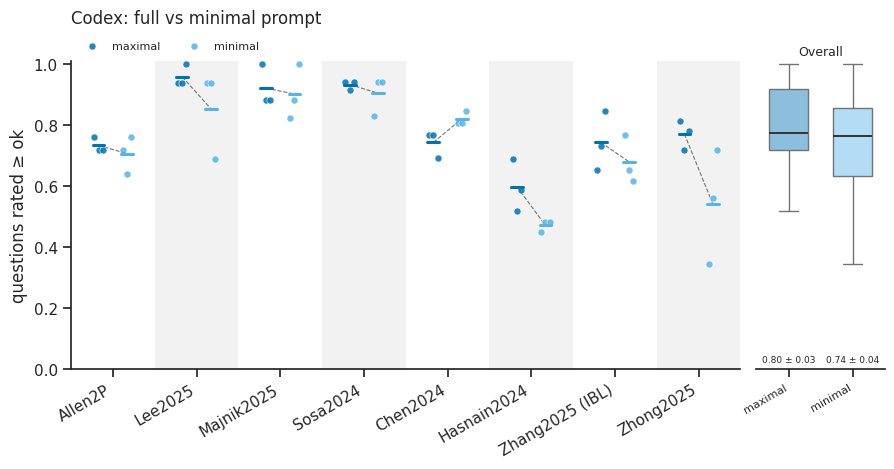

In [34]:
for agent in ("claude-code", "codex"):
    pair = (f"{agent}/full", f"{agent}/minimal")
    fig, _ = conditions.condition_scatter(
        scores, conditions=pair, ylim=(0.0, 1.01),
        title=f"{experiments.AGENT_LABEL[agent]}: full vs minimal prompt")
    plt.show()

## 4. Ratings

The distribution behind section 2's and 3's single numbers: the `ok`, `match`
and `better` bars are exactly the `frac_ok` numerator plotted above. Same four
comparisons, same colors.

`combined` is the element-wise max of the two judges, so the two ends of the
axis are not symmetric: `incorrect` means **both** judges said incorrect, while
`better` means **either** did. That is the rule the rest of the notebook uses at
the ok/concerning boundary, but it does inflate `better` (82 here against 46 and
37 for the two judges separately).

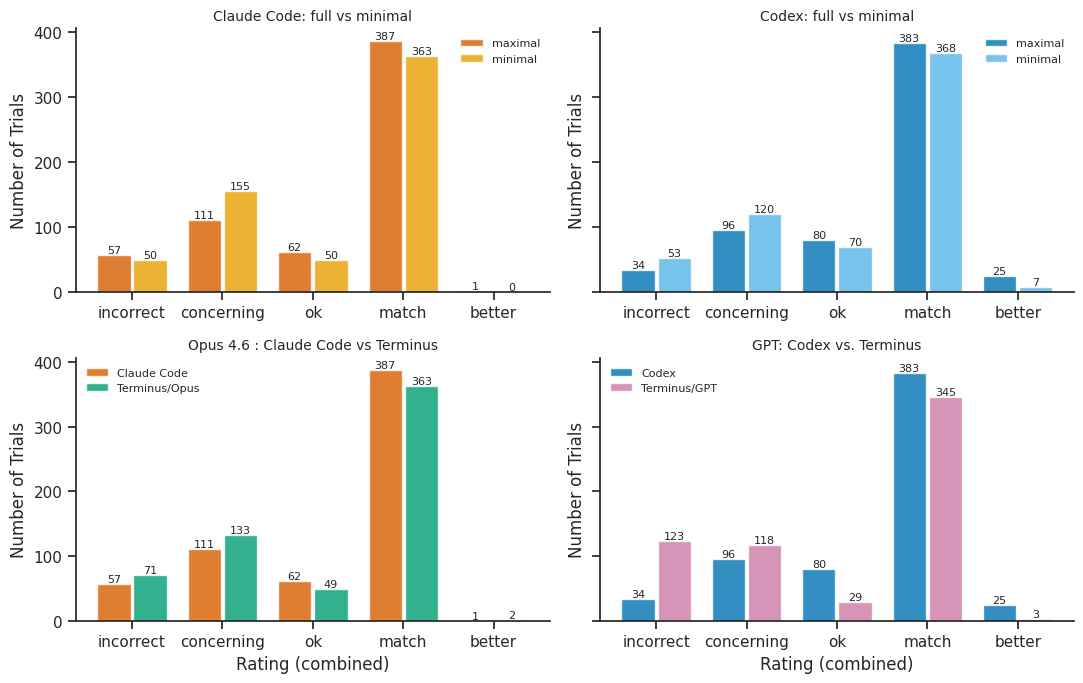

In [35]:
# The same four pairings as above — six conditions in one panel was too many to
# read, and each of these is a comparison we actually make.
COMPARISONS = [
    ("Claude Code: full vs minimal", ("claude-code/full", "claude-code/minimal")),
    ("Codex: full vs minimal",       ("codex/full", "codex/minimal")),
    ("Opus 4.6 : Claude Code vs Terminus", CLAUDE_PAIR),
    ("GPT: Codex vs. Terminus",           GPT_PAIR),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)
for ax, (title, pair) in zip(axes.ravel(), COMPARISONS):
    plots.rating_levels(process_only, rater="combined", ax=ax, group="condition",
                        order=pair, labels=conditions.condition_labels(pair),
                        colors=CONDITION_COLOR)
    ax.set_title(title, fontsize=10)
    ax.legend(fontsize=8, frameon=False)
for ax in axes[0]:            # x label only under the bottom row
    ax.set_xlabel("")
fig.tight_layout()
plt.show()

## 5. Which part does each condition differ from each other?

The same figure with question bands on the x axis instead of datasets — the
bands the summary visualization uses: Data Loading and Neural Data whole, and
Data Variables split into what the question asks about. One point is **one dataset**, 
its three trials pooled: trials repeat within a dataset, so they average, while the 
eight datasets are the independent samples of a condition's score in that band.

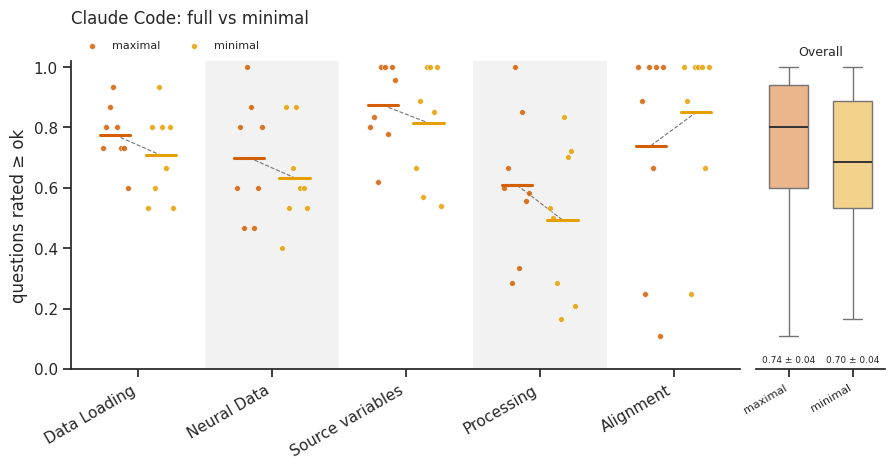

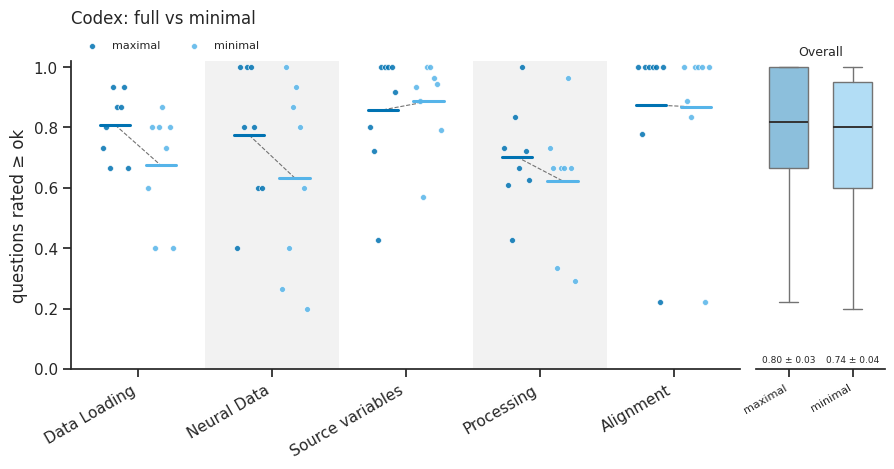

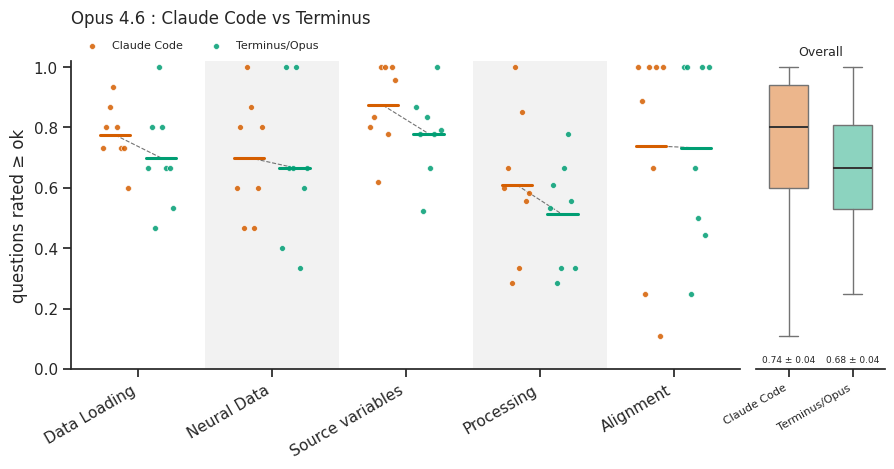

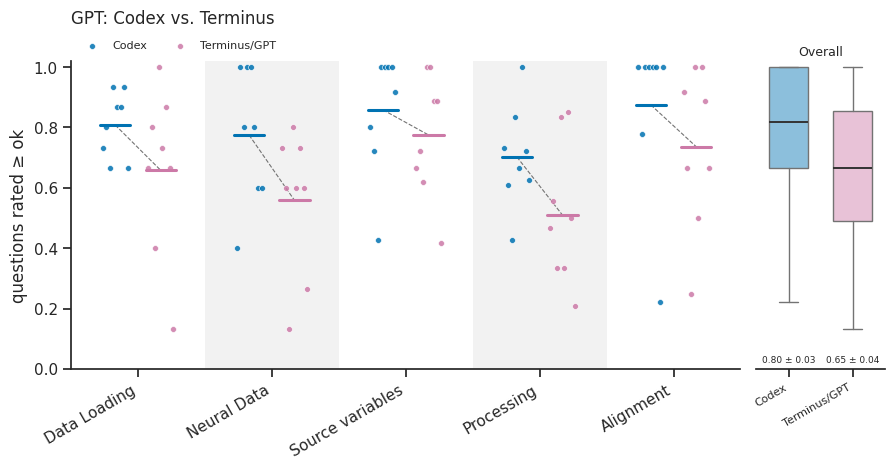

In [36]:
by_group = process_only.assign(group=conditions.question_group(process_only))
by_group = by_group[by_group.group.isin(conditions.QUESTION_GROUPS)]
group_scores = conditions.condition_scores(by_group, rater="combined",
                                           by="group", unit="dataset")

for title, pair in COMPARISONS:
    fig, _ = conditions.condition_scatter(
        group_scores, conditions=pair, x="group",
        order=list(conditions.QUESTION_GROUPS), title=title)
    plt.show()